**DATA IMPORT AND BASIC EXPLORARION**

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_inline
import matplotlib.ticker as mtick


In [159]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [160]:
df.dropna(axis =0, inplace = True)
df.head

<bound method NDFrame.head of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender   Age  \
0             1    15634602   Hargrave          619    France  Female  42.0   
1             2    15647311       Hill          608     Spain  Female  41.0   
2             3    15619304       Onio          502    France  Female  42.0   
3             4    15701354       Boni          699    France  Female  39.0   
4             5    15737888   Mitchell          850     Spain  Female  43.0   
...         ...         ...        ...          ...       ...     ...   ...   
9994       9995    15719294       Wood          800    France  Female  29.0   
9996       9997    15569892  Johnstone          516    France    Male  35.0   
9997       9998    15584532        Liu          709    France  Female  36.0   
9998       9999    15682355  Sabbatini          772   Germany    Male  42.0   
9999      10000    15628319     Walker          792    France  Female  28.0   

      Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0          2       0.00              1          1               1   
1          1   83807.86              1          0               1   
2          8  159660.80              3          1               0   
3          1       0.00              2          0               0   
4          2  125510.82              1          1               1   
...      ...        ...            ...        ...             ...   
9994       2       0.00              2          0               0   
9996      10   57369.61              1          1               1   
9997       7       0.00              1          0               1   
9998       3   75075.31              2          1               0   
9999       4  130142.79              1          1               0   

      EstimatedSalary  Exited  
0           101348.88       1  
1           112542.58       0  
2           113931.57       1  
3            93826.63       0  
4            79084.10       0  
...               ...     ...  
9994        167773.55       0  
9996        101699.77       0  
9997         42085.58       1  
9998         92888.52       1  
9999         38190.78       0  

[9740 rows x 14 columns]>

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9740 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9740 non-null   int64  
 1   CustomerId       9740 non-null   int64  
 2   Surname          9740 non-null   object 
 3   CreditScore      9740 non-null   int64  
 4   Geography        9740 non-null   object 
 5   Gender           9740 non-null   object 
 6   Age              9740 non-null   float64
 7   Tenure           9740 non-null   int64  
 8   Balance          9740 non-null   float64
 9   NumOfProducts    9740 non-null   int64  
 10  HasCrCard        9740 non-null   int64  
 11  IsActiveMember   9740 non-null   int64  
 12  EstimatedSalary  9740 non-null   float64
 13  Exited           9740 non-null   int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


**Analyze Individual Variables (Univariate Analysis)**

 **Numerical**:

Histogram

Box plot

Density plot

**Categorical**:

Count plot

Bar chart

Frequency table


In [162]:
df_new = df[['Geography','Gender','Exited']]
df_new.head()

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


In [163]:
df_new.Exited.value_counts()


,count
Exited,
0,7751
1,1989


In [164]:
df_new.Exited.value_counts()/ len(df_new)*100


,count
Exited,
0,79.579055
1,20.420945


**Univariate Analysis**

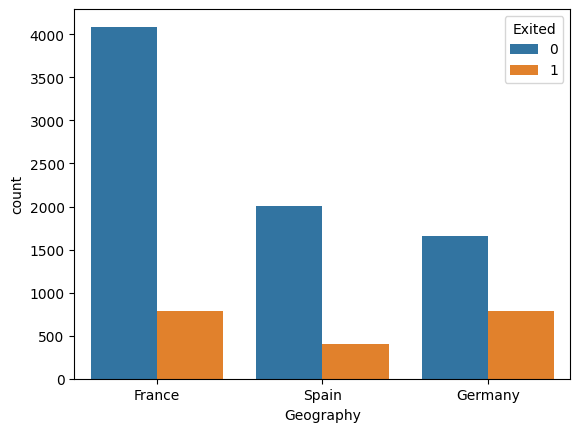

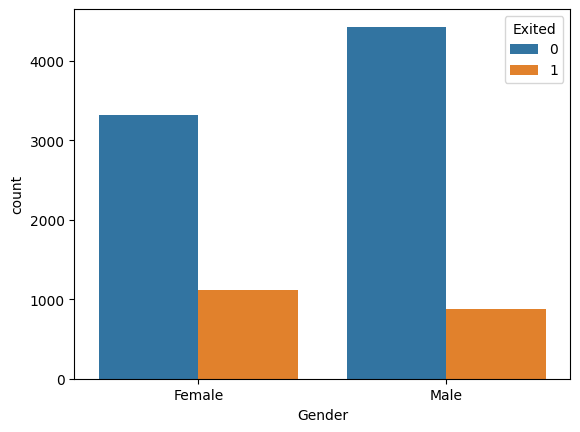

In [165]:
for i , predictor in enumerate (df_new.drop(columns=['Exited'])):
  plt.figure(i)
  sns.countplot(data = df_new, x = predictor, hue= 'Exited')



**Analyze Relationships Between Variables (Bivariate Analysis)**

**Numerical vs. Numerical**:

Scatter plot

Correlation matrix

**Categorical vs. Numerical**:

Box plot

Violin plot

Categorical vs. Categorical:

Cross-tabulation

Stacked bar chart

**Bivariate Analysis**

<Axes: xlabel='Gender', ylabel='Count'>

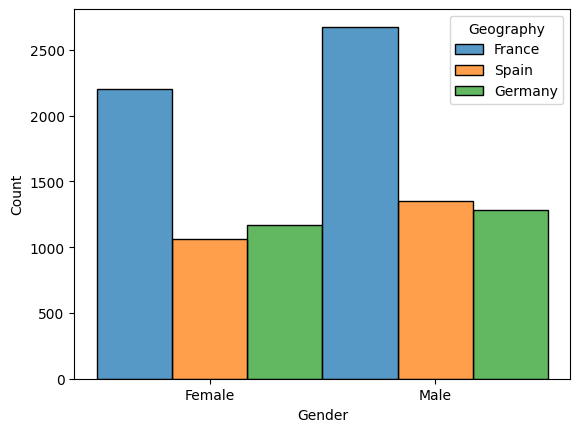

In [166]:
sns.histplot(x = 'Gender', hue = 'Geography', data = df_new, multiple = "dodge")  #Categorial Analysis

In [167]:
df_new1 = df_new.loc[df_new['Exited'] ==1]
df_new1.head()

,Geography,Gender,Exited
0,France,Female,1
2,France,Female,1
5,Spain,Male,1
7,Germany,Female,1
16,Germany,Male,1


<Axes: xlabel='Gender', ylabel='Count'>

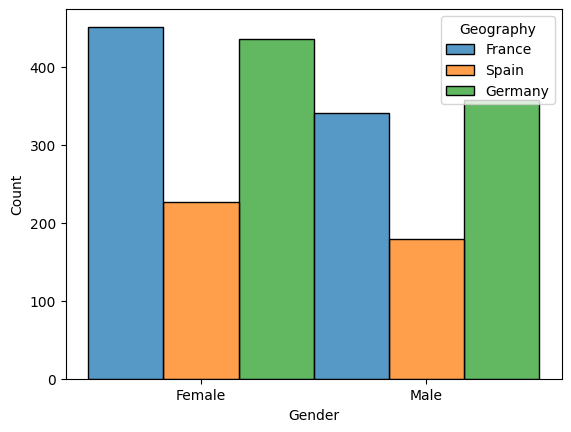

In [168]:
sns.histplot(x ='Gender', hue= 'Geography', data = df_new1, multiple = 'dodge')

**Numerical Analysis**

correlatio: it ranges from -1 to +1



*   +1--> Positive Correlation
*   -1--> Negative Correlation


*   0 --> No Correlation






In [169]:
df.select_dtypes(include=np.number).corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.006900,0.004046,0.001330,-0.005884,-0.007098,0.009007,-0.000580,0.012389,-0.006169,-0.014883
CustomerId,0.006900,1.000000,0.006809,0.008095,-0.012853,-0.012716,0.016429,-0.012752,0.001014,0.013278,-0.006250
CreditScore,0.004046,0.006809,1.000000,-0.004357,-0.001728,0.005633,0.011219,-0.004291,0.026207,0.002123,-0.027520
Age,0.001330,0.008095,-0.004357,1.000000,-0.011997,0.030637,-0.028853,-0.012975,0.087788,-0.007110,0.286641
Tenure,-0.005884,-0.012853,-0.001728,-0.011997,1.000000,-0.014059,0.012889,0.024427,-0.030262,0.007798,-0.015960
Balance,-0.007098,-0.012716,0.005633,0.030637,-0.014059,1.000000,-0.303323,-0.013653,-0.006582,0.011224,0.119390
NumOfProducts,0.009007,0.016429,0.011219,-0.028853,0.012889,-0.303323,1.000000,0.003635,0.010253,0.013004,-0.047417
HasCrCard,-0.000580,-0.012752,-0.004291,-0.012975,0.024427,-0.013653,0.003635,1.000000,-0.012616,-0.007971,-0.008220
IsActiveMember,0.012389,0.001014,0.026207,0.087788,-0.030262,-0.006582,0.010253,-0.012616,1.000000,-0.011204,-0.155348
EstimatedSalary,-0.006169,0.013278,0.002123,-0.007110,0.007798,0.011224,0.013004,-0.007971,-0.011204,1.000000,0.012619


<Axes: >

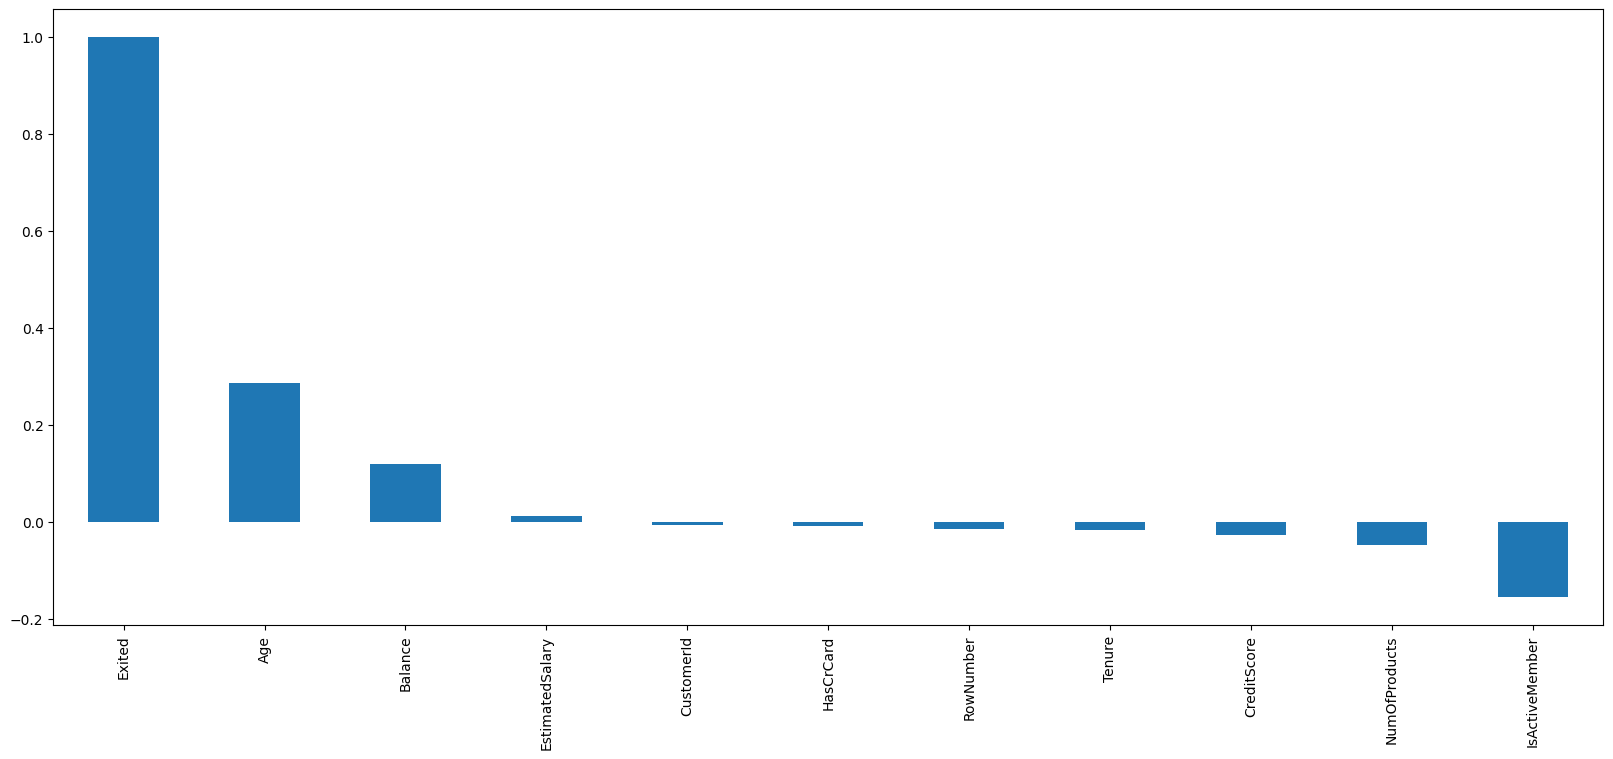

In [170]:
plt.figure(figsize = (20,8))
df.select_dtypes(include= np.number).corr()['Exited'].sort_values(ascending=False).plot(kind= 'bar')

In [171]:
df.select_dtypes(include=np.number).corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.006900,0.004046,0.001330,-0.005884,-0.007098,0.009007,-0.000580,0.012389,-0.006169,-0.014883
CustomerId,0.006900,1.000000,0.006809,0.008095,-0.012853,-0.012716,0.016429,-0.012752,0.001014,0.013278,-0.006250
CreditScore,0.004046,0.006809,1.000000,-0.004357,-0.001728,0.005633,0.011219,-0.004291,0.026207,0.002123,-0.027520
Age,0.001330,0.008095,-0.004357,1.000000,-0.011997,0.030637,-0.028853,-0.012975,0.087788,-0.007110,0.286641
Tenure,-0.005884,-0.012853,-0.001728,-0.011997,1.000000,-0.014059,0.012889,0.024427,-0.030262,0.007798,-0.015960
Balance,-0.007098,-0.012716,0.005633,0.030637,-0.014059,1.000000,-0.303323,-0.013653,-0.006582,0.011224,0.119390
NumOfProducts,0.009007,0.016429,0.011219,-0.028853,0.012889,-0.303323,1.000000,0.003635,0.010253,0.013004,-0.047417
HasCrCard,-0.000580,-0.012752,-0.004291,-0.012975,0.024427,-0.013653,0.003635,1.000000,-0.012616,-0.007971,-0.008220
IsActiveMember,0.012389,0.001014,0.026207,0.087788,-0.030262,-0.006582,0.010253,-0.012616,1.000000,-0.011204,-0.155348
EstimatedSalary,-0.006169,0.013278,0.002123,-0.007110,0.007798,0.011224,0.013004,-0.007971,-0.011204,1.000000,0.012619


<Axes: >

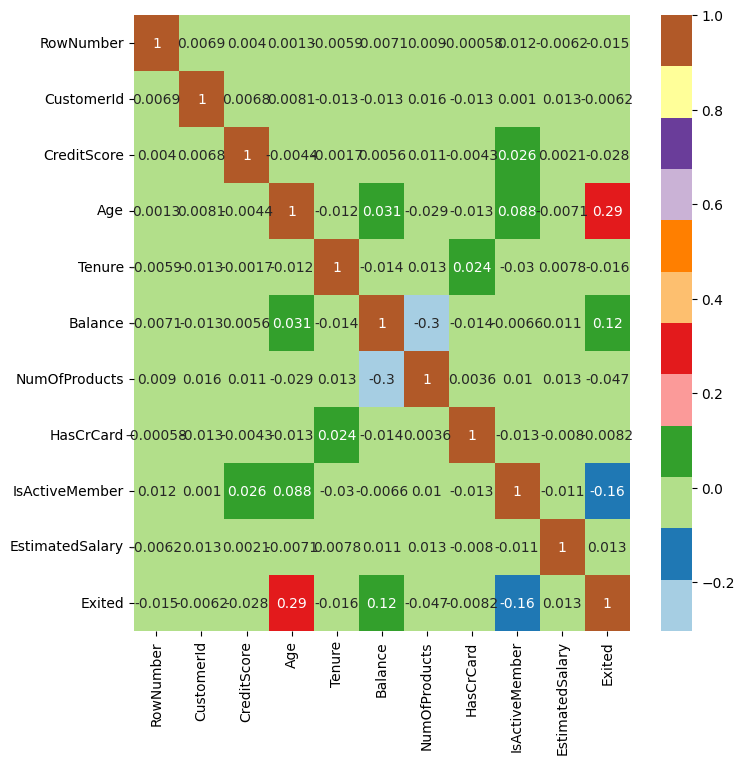

In [172]:
plt.figure(figsize = (8,8))
sns.heatmap(df.select_dtypes(include= np.number).corr(), cmap='Paired', annot = True)  #Heatmap

<Axes: xlabel='Age'>

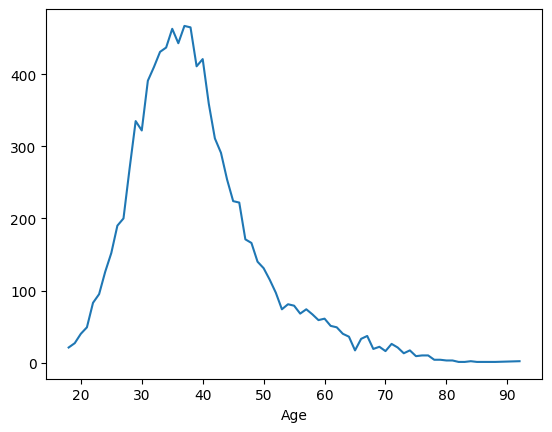

In [173]:
df['Age'].value_counts().sort_index(ascending=True).plot()

In [174]:
df_new1 = df.loc[df['Exited']==1]

<Axes: xlabel='Age'>

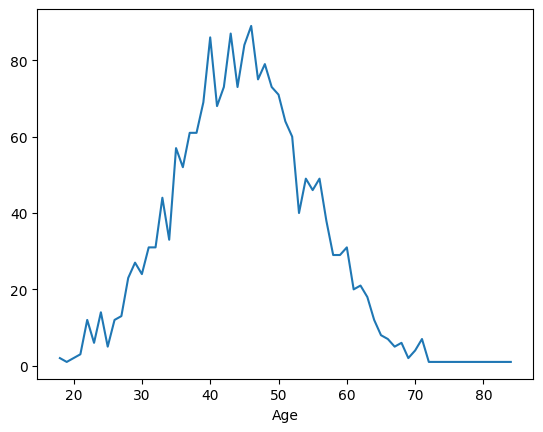

In [175]:
df_new1['Age'].value_counts().sort_index(ascending=True).plot()

/tmp/ipykernel_2000/2478701400.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Age[(df['Exited']==0)], color='Red', shade = True)
/tmp/ipykernel_2000/2478701400.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Age[(df['Exited']==1)], color='Blue', shade = True)


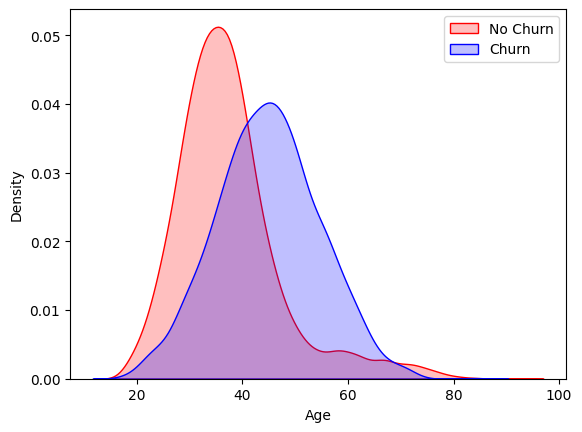

In [176]:
Tot = sns.kdeplot(df.Age[(df['Exited']==0)], color='Red', shade = True)
Tot = sns.kdeplot(df.Age[(df['Exited']==1)], color='Blue', shade = True)
Tot.legend(["No Churn", "Churn"], loc ='upper right')
Tot.set_ylabel= 'Density'
Tot.set_xlabel= 'Age'
Tot.set_title= 'Age by Churn'

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9740 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9740 non-null   int64  
 1   CustomerId       9740 non-null   int64  
 2   Surname          9740 non-null   object 
 3   CreditScore      9740 non-null   int64  
 4   Geography        9740 non-null   object 
 5   Gender           9740 non-null   object 
 6   Age              9740 non-null   float64
 7   Tenure           9740 non-null   int64  
 8   Balance          9740 non-null   float64
 9   NumOfProducts    9740 non-null   int64  
 10  HasCrCard        9740 non-null   int64  
 11  IsActiveMember   9740 non-null   int64  
 12  EstimatedSalary  9740 non-null   float64
 13  Exited           9740 non-null   int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


/tmp/ipykernel_2000/2365461036.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Balance [(df['Exited']==0)], color='Red', shade = True)
/tmp/ipykernel_2000/2365461036.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Balance [(df['Exited']==1)], color='Blue', shade = True)


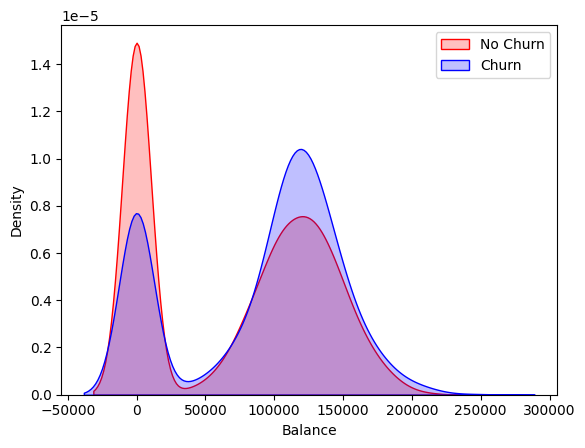

In [178]:
Tot = sns.kdeplot(df.Balance [(df['Exited']==0)], color='Red', shade = True)
Tot = sns.kdeplot(df.Balance [(df['Exited']==1)], color='Blue', shade = True)
Tot.legend(["No Churn", "Churn"], loc ='upper right')
Tot.set_ylabel= 'Density'
Tot.set_xlabel= 'Balance          '
Tot.set_title= 'Balance by Churn'

/tmp/ipykernel_2000/3582611946.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Tenure [(df['Exited']==0)], color='Red', shade = True)
/tmp/ipykernel_2000/3582611946.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Tenure [(df['Exited']==1)], color='Blue', shade = True)


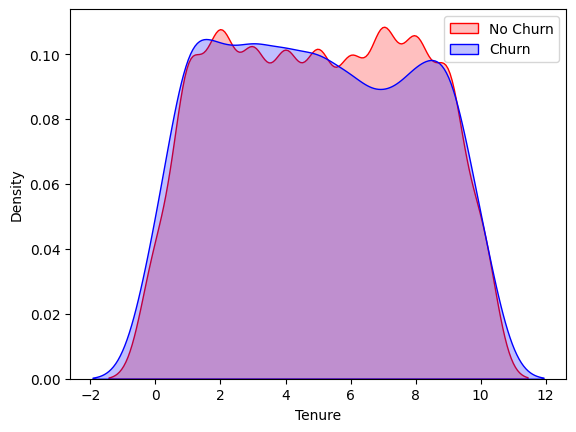

In [179]:
Tot = sns.kdeplot(df.Tenure [(df['Exited']==0)], color='Red', shade = True)
Tot = sns.kdeplot(df.Tenure [(df['Exited']==1)], color='Blue', shade = True)
Tot.legend(["No Churn", "Churn"], loc ='upper right')
Tot.set_ylabel= 'Density'
Tot.set_xlabel= 'Tenure          '
Tot.set_title= 'Tenure by Churn'